# GCC Dataset Preprocessing Notebook

This notebook details the preprocessing steps applied to the Google Conceptual Captions (GCC) dataset components: training captions/URLs, validation captions/URLs, and image labels. The goal is to clean the data, merge relevant information, download and validate images, and prepare the dataset for further use, potentially in training image captioning or related multimodal models.

## 1. Setup

First, we ensure necessary libraries are installed. Then, we import all required Python libraries for data manipulation, image handling, asynchronous operations, visualization, and define configuration variables used throughout the notebook.

In [4]:
# --- Ensure required libraries are installed ---
# Uncomment the line below if you need to install the packages
!pip install pandas pillow tqdm matplotlib requests aiohttp aiofiles nest_asyncio pyarrow seaborn


In [5]:

# --- Import necessary libraries ---
import os
import json
import re
import asyncio
import nest_asyncio
from io import BytesIO
from collections import Counter

import pandas as pd
import numpy as np
from PIL import Image
import requests
import aiohttp
import aiofiles
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns # Using seaborn for potentially nicer default plots

# --- Configuration Variables ---
DATA_PATH = 'data'  # Base directory for data files
SUBSET_SIZE = 200000 # Size of the training subset for development/downloading
CONCURRENT_REQUESTS = 100  # Max concurrent image downloads
IMAGE_TIMEOUT = 10         # Timeout in seconds for downloading a single image
FIGURE_SAVE_DIR = "figures" # Directory to save generated plots
NUM_COMMON_WORDS_TO_PLOT = 30 # Number of top words to plot in the frequency chart

# --- Plot Styling (Optional) ---
def setup_scientific_plot_style():
    """Applies basic styling suitable for scientific papers."""
    try:
        # Use a modern seaborn style if available
        plt.style.use('seaborn-v0_8-paper')
    except:
        # Fallback to default if seaborn style isn't found
        plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 12,
        'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 9,
        'figure.titlesize': 13, 'figure.dpi': 150, 'savefig.dpi': 300,
        'savefig.bbox': 'tight', 'lines.linewidth': 1.5,
        'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.7
    })
setup_scientific_plot_style()

# --- Setup for Asynchronous Operations in Jupyter ---
# Allow nested asyncio loops, needed for running async code in notebook environments
nest_asyncio.apply()

# --- Ensure figure directory exists ---
os.makedirs(FIGURE_SAVE_DIR, exist_ok=True)

print("Setup complete. Libraries imported and configuration set.")

Setup complete. Libraries imported and configuration set.


## 2. Data Loading

We load the three provided TSV files into pandas DataFrames:
1.  **Training Data:** Contains image captions and their corresponding URLs.
2.  **Validation Data:** Similar structure to training data, used for model validation.
3.  **Image Labels Data:** Contains machine-generated labels (often similar to captions) and URLs for a subset of the training images.

*Note: The original TSV files use tab separation. We handle potential malformed lines during loading.*

In [10]:
# Load training data (Caption, URL)
train_data = []
train_file_path = os.path.join(DATA_PATH, 'Train_GCC-training.tsv')
print(f"Loading training data from {train_file_path}...")
try:
    with open(train_file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading Train TSV"):
            parts = line.strip().split('\t')
            if len(parts) == 2:
                caption, url = parts # Original order
                train_data.append({'url': url, 'caption': caption}) # Store with consistent keys
            else:
                # Optionally log malformed lines instead of printing all
                # print(f"Skipping malformed train line: {line.strip()}")
                pass # Silently skip for cleaner output
except FileNotFoundError:
    print(f"ERROR: Training data file not found at {train_file_path}")
    train_df = pd.DataFrame(columns=['url', 'caption']) # Create empty df
else:
    train_df = pd.DataFrame(train_data)
    print(f"Loaded {len(train_df):,} training samples.")

# Load validation data (Caption, URL)
val_data = []
val_file_path = os.path.join(DATA_PATH, 'Validation_GCC-1.1.0-Validation.tsv')
print(f"\nLoading validation data from {val_file_path}...")
try:
    with open(val_file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading Validation TSV"):
             parts = line.strip().split('\t')
             if len(parts) == 2:
                caption, url = parts # Original order
                val_data.append({'url': url, 'caption': caption}) # Store with consistent keys
             else:
                # print(f"Skipping malformed validation line: {line.strip()}")
                pass
except FileNotFoundError:
    print(f"ERROR: Validation data file not found at {val_file_path}")
    val_df = pd.DataFrame(columns=['url', 'caption'])
else:
    val_df = pd.DataFrame(val_data)
    print(f"Loaded {len(val_df):,} validation samples.")

# Load image labels data (Labels, URL) - More robust parsing
labels_data = []
labels_file_path = os.path.join(DATA_PATH, 'Image_Labels_Subset_Train_GCC-Labels-training.tsv')
print(f"\nLoading labels data from {labels_file_path}...")
skipped_no_url = 0
skipped_short = 0
try:
    with open(labels_file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Loading Labels TSV"):
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                url = None
                url_index = -1
                # Find the first part that looks like a URL
                for i, part in enumerate(parts):
                    if part.startswith(('http://', 'https://')):
                        url = part
                        url_index = i
                        break # Assume the first URL found is the one

                if url is not None:
                    # Reconstruct the label from parts *not* including the URL
                    label_parts = parts[:url_index] + parts[url_index+1:]
                    labels = '\t'.join(label_parts) # Rejoin if label had tabs
                    labels_data.append({'url': url, 'labels': labels})
                else:
                    # print(f"Skipping line - no URL found: {line.strip()}") # Optional: log skips
                    skipped_no_url += 1
                    pass
            else:
                 # print(f"Skipping line with insufficient columns: {line.strip()}") # Optional: log skips
                 skipped_short += 1
                 pass
except FileNotFoundError:
     print(f"ERROR: Labels data file not found at {labels_file_path}")
     labels_df = pd.DataFrame(columns=['url', 'labels'])
else:
    labels_df = pd.DataFrame(labels_data)
    print(f"Loaded {len(labels_df):,} label samples.")
    if skipped_no_url > 0:
        print(f"Skipped {skipped_no_url:,} lines because no URL pattern was found.")
    if skipped_short > 0:
        print(f"Skipped {skipped_short:,} lines because they had fewer than 2 tab-separated parts.")

Loading training data from data/Train_GCC-training.tsv...


Loading Train TSV: 0it [00:00, ?it/s]

Loaded 3,318,333 training samples.

Loading validation data from data/Validation_GCC-1.1.0-Validation.tsv...


Loading Validation TSV: 0it [00:00, ?it/s]

Loaded 15,840 validation samples.

Loading labels data from data/Image_Labels_Subset_Train_GCC-Labels-training.tsv...


Loading Labels TSV: 0it [00:00, ?it/s]

Loaded 2,007,528 label samples.


## 3. Initial Data Exploration

Let's examine the basic properties of our loaded data, such as the number of entries (rows) and look at a few examples. We also check for any completely empty rows, which might indicate loading issues.

Initial DataFrame Shapes:
Train data shape: (3318333, 2)
Validation data shape: (15840, 2)
Labels data shape: (2007528, 2)

Figure 1 (Initial Shapes) saved to figures/figure_1_initial_shapes.png


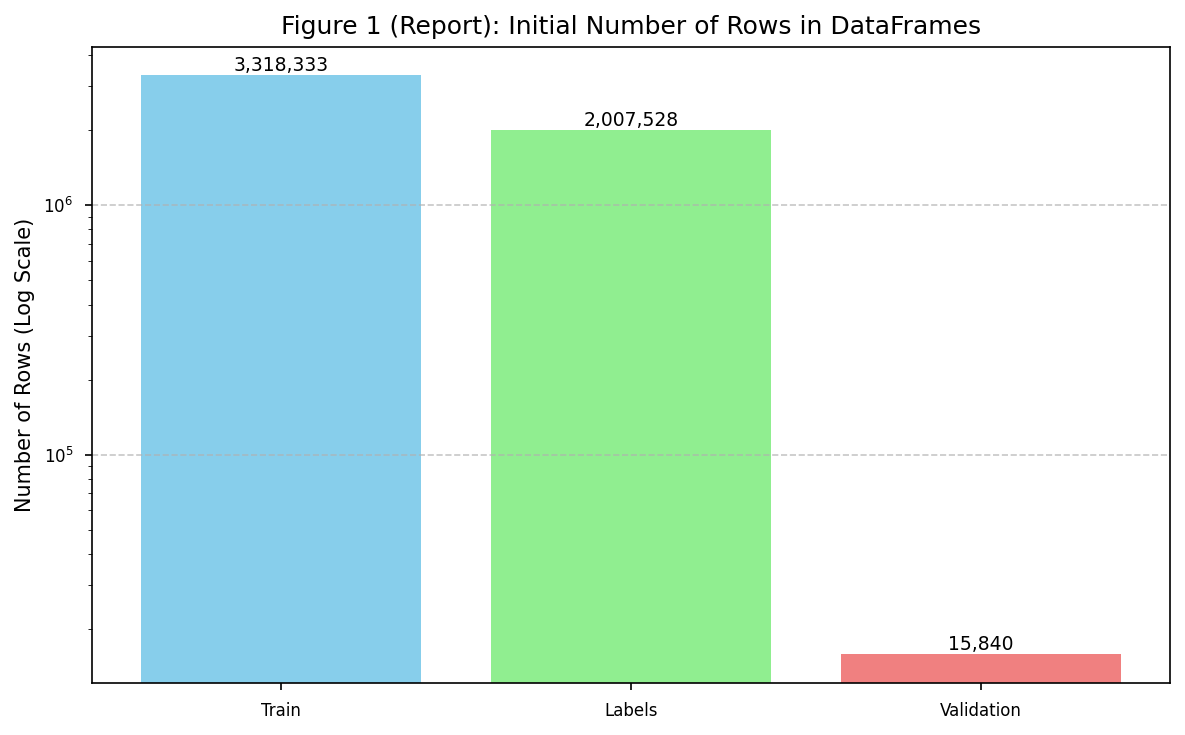


Train data head:
                                                 url  \
0  http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...   
1  http://78.media.tumblr.com/3b133294bdc7c7784b7...   
2  https://media.gettyimages.com/photos/young-con...   
3  https://thumb1.shutterstock.com/display_pic_wi...   
4  https://thumb1.shutterstock.com/display_pic_wi...   

                                             caption  
0                         a very typical bus station  
1  sierra looked stunning in this top and this sk...  
2  young confused girl standing in front of a war...  
3  interior design of modern living room with fir...  
4    cybernetic scene isolated on white background .  

Validation data head:
                                                 url  \
0  https://i.pinimg.com/736x/66/01/6c/66016c3ba27...   
1  http://www.standard.net/image/2015/02/04/800x_...   
2  http://indianapolis-photos.funcityfinder.com/f...   
3  http://www.abc.net.au/news/image/9066492-3x2-7...   
4  https://w

In [12]:
# --- Display Shapes ---
print("Initial DataFrame Shapes:")
print(f"Train data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Labels data shape: {labels_df.shape}")

# --- Plot Shapes ---
def plot_dataframe_shapes(shapes_dict):
    """Plots the number of rows of DataFrames."""
    names = list(shapes_dict.keys())
    # Ensure shapes are valid before accessing index 0
    rows = [shape[0] if len(shape) > 0 else 0 for shape in shapes_dict.values()]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, rows, color=['skyblue', 'lightgreen', 'lightcoral'])
    plt.title("Figure 1 (Report): Initial Number of Rows in DataFrames")
    plt.ylabel("Number of Rows (Log Scale)")
    plt.yscale('log') # Use log scale due to large difference in sample counts
    # Add data labels above bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center', fontsize=9)
    plt.xticks(rotation=0)
    plt.grid(axis='x', which='both', linestyle='', linewidth=0) # Clean up x-axis grid for log scale
    plt.tight_layout()
    # Save the figure
    figure_path_shapes = os.path.join(FIGURE_SAVE_DIR, "figure_1_initial_shapes.png")
    plt.savefig(figure_path_shapes)
    print(f"\nFigure 1 (Initial Shapes) saved to {figure_path_shapes}")
    plt.show()

shapes = {'Train': train_df.shape, 'Labels': labels_df.shape, 'Validation': val_df.shape}
plot_dataframe_shapes(shapes)

# --- Display Head ---
print("\nTrain data head:")
print(train_df.head())
print("\nLabels data head:")
print(labels_df.head())
print("\nValidation data head:")
print(val_df.head())

In [14]:
# --- Check for Empty Rows ---
def check_empty_rows(df, name="DataFrame"):
    """Checks for and reports completely empty rows."""
    if df.empty:
      print(f"{name} is empty. Cannot check for empty rows.")
      return False
    empty_rows = df.isnull().all(axis=1)
    num_empty = empty_rows.sum()
    if num_empty > 0:
        print(f"WARNING: Found {num_empty} completely empty rows in {name}.")
        # print(df[empty_rows]) # Optionally print the empty rows
    else:
        print(f"No completely empty rows found in {name}.")
    return num_empty > 0

print("\nChecking for Empty Rows:")
_ = check_empty_rows(train_df, "Train DF")
_ = check_empty_rows(val_df, "Validation DF")
_ = check_empty_rows(labels_df, "Labels DF")


Checking for Empty Rows:
No completely empty rows found in Train DF.
No completely empty rows found in Validation DF.
No completely empty rows found in Labels DF.


## 4. Data Merging and Cleaning

The `labels_df` contains labels only for a *subset* of the training images. We merge this with `train_df` using the image URL as the key. A left merge ensures we keep all training captions, adding labels where available. This introduces `NaN` values for captions without corresponding labels in the subset file.

After merging, we remove rows with `NaN` labels, effectively filtering our training set to only include samples present in the provided label subset file.

Finally, we clean the 'caption' and 'labels' text by:
- Converting to lowercase.
- Removing punctuation (keeping only word characters and whitespace).
- Standardizing whitespace (collapsing multiple spaces into one).

In [15]:
# --- Merge Training Data with Labels ---
print("Merging training data with labels data based on URL...")
# First, check for and handle duplicate URLs in the *left* dataframe (train_df)
# as merge validation='1:1' or '1:m' fails if left keys aren't unique.
train_url_duplicates = train_df.url.duplicated().sum()
if train_url_duplicates > 0:
    print(f"WARNING: Found {train_url_duplicates} duplicate URLs in the training data. Keeping the first instance.")
    train_df_unique = train_df.drop_duplicates(subset='url', keep='first')
else:
    train_df_unique = train_df

# Check for duplicates in the *right* dataframe (labels_df) - less critical for left merge but good to know
labels_url_duplicates = labels_df.url.duplicated().sum()
if labels_url_duplicates > 0:
     print(f"INFO: Found {labels_url_duplicates} duplicate URLs in the labels data. Left merge will handle this.")

# Perform the left merge
try:
    # Use the train_df with unique URLs for the merge
    train_df_merged = pd.merge(train_df_unique, labels_df, on='url', how='left')
except Exception as e:
    print(f"An unexpected error occurred during merge: {e}")
    # Handle error, maybe create an empty DataFrame or exit
    train_df_merged = pd.DataFrame(columns=['url', 'caption', 'labels'])

print("Merge complete.")
print(f"Shape after merge (before NaN removal): {train_df_merged.shape}")
print("\nMerged Train data head (before NaN removal):")
print(train_df_merged.head())

Merging training data with labels data based on URL...
Merge complete.
Shape after merge (before NaN removal): (3317812, 3)

Merged Train data head (before NaN removal):
                                                 url  \
0  http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...   
1  http://78.media.tumblr.com/3b133294bdc7c7784b7...   
2  https://media.gettyimages.com/photos/young-con...   
3  https://thumb1.shutterstock.com/display_pic_wi...   
4  https://thumb1.shutterstock.com/display_pic_wi...   

                                             caption  \
0                         a very typical bus station   
1  sierra looked stunning in this top and this sk...   
2  young confused girl standing in front of a war...   
3  interior design of modern living room with fir...   
4    cybernetic scene isolated on white background .   

                                              labels  
0  a very typical bus station\tmode of transport,...  
1  sierra looked stunning in this top and this


--- NaN Analysis After Merge ---
Total NaN values in merged DataFrame: 1,310,284

NaN values per column:
url              0
caption          0
labels     1310284
dtype: int64


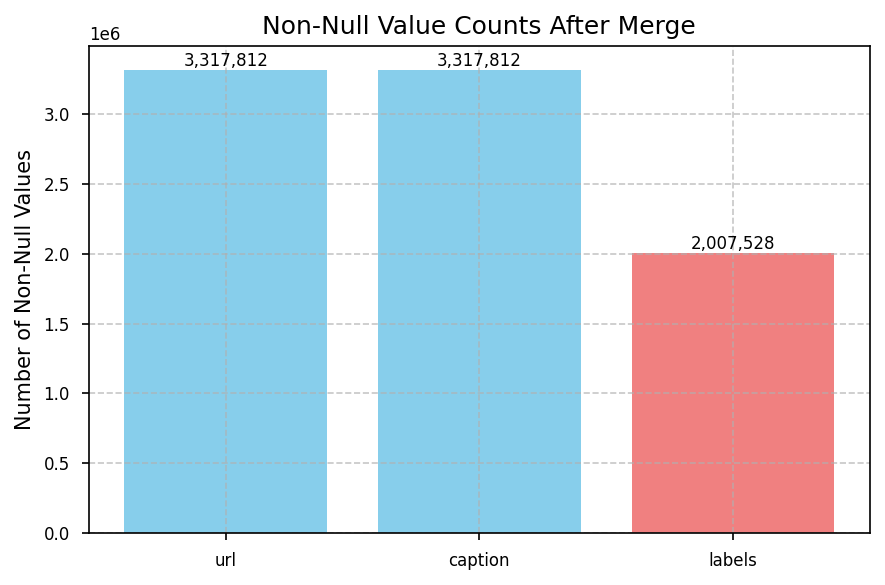

In [16]:
# --- Analyze NaN values introduced by the merge ---
print("\n--- NaN Analysis After Merge ---")
if not train_df_merged.empty:
    total_na = train_df_merged.isna().sum().sum()
    na_per_column = train_df_merged.isna().sum()

    print(f"Total NaN values in merged DataFrame: {total_na:,}")
    print("\nNaN values per column:")
    print(na_per_column)

    # Plot non-null values for visualization
    plt.figure(figsize=(6, 4))
    non_null_counts = train_df_merged.count() # Counts non-NaN values
    colors = ['skyblue' if col != 'labels' else 'lightcoral' for col in non_null_counts.index]
    bars = plt.bar(non_null_counts.index, non_null_counts.values, color=colors)
    plt.title('Non-Null Value Counts After Merge')
    plt.ylabel('Number of Non-Null Values')
    plt.xticks(rotation=0)
    # Add data labels
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Merged DataFrame is empty, skipping NaN analysis.")

In [17]:
# --- Remove Rows with Missing Labels ---
# These are rows from the original train_df that did not have a match in labels_df
print("\nRemoving rows where 'labels' are NaN (filtering to label subset)...")
if not train_df_merged.empty:
    initial_rows = len(train_df_merged)
    train_df_cleaned = train_df_merged.dropna(subset=["labels"])
    rows_removed = initial_rows - len(train_df_cleaned)
    print(f"Removed {rows_removed:,} rows with missing labels.")
    print(f"Shape after NaN removal: {train_df_cleaned.shape}")

    # Reset the index after dropping rows for clean indexing
    train_df_cleaned = train_df_cleaned.reset_index(drop=True)
else:
    print("Merged DataFrame is empty, skipping NaN removal.")
    train_df_cleaned = train_df_merged.copy() # Keep it empty


Removing rows where 'labels' are NaN (filtering to label subset)...
Removed 1,310,284 rows with missing labels.
Shape after NaN removal: (2007528, 3)


In [18]:
# --- Text Cleaning ---
# Define function to clean text data
def clean_caption(caption):
    """Converts to lowercase, removes punctuation (keeps words/spaces), and standardizes whitespace."""
    if not isinstance(caption, str):
        return "" # Handle potential non-string data gracefully
    caption = caption.lower()
    # Remove characters that are NOT word characters (\w) or whitespace (\s)
    caption = re.sub(r'[^\w\s]', '', caption)
    # Replace multiple whitespace characters with a single space and strip ends
    caption = re.sub(r'\s+', ' ', caption).strip()
    return caption

# Apply cleaning to 'caption' and 'labels' columns in the cleaned dataframe
print("\nCleaning caption and label text...")
if not train_df_cleaned.empty:
    # Use .loc to avoid SettingWithCopyWarning
    train_df_cleaned.loc[:, 'cleaned_caption'] = train_df_cleaned['caption'].apply(clean_caption)
    train_df_cleaned.loc[:, 'cleaned_label'] = train_df_cleaned['labels'].apply(clean_caption)
    print("Text cleaning complete.")

    # Display head with cleaned columns
    print("\nDataFrame head after text cleaning:")
    print(train_df_cleaned[['caption', 'cleaned_caption', 'labels', 'cleaned_label']].head())
else:
     print("Cleaned DataFrame is empty, skipping text cleaning.")

# Also clean validation captions for consistency if needed later
if not val_df.empty:
    val_df.loc[:, 'cleaned_caption'] = val_df['caption'].apply(clean_caption)
    # Add dummy label columns if they will be needed for schema consistency
    if 'labels' not in val_df.columns:
         val_df.loc[:, 'labels'] = val_df['caption'] # Or set to NaN/empty string
    if 'cleaned_label' not in val_df.columns:
         val_df.loc[:, 'cleaned_label'] = val_df['cleaned_caption']
    print("\nValidation captions cleaned.")


Cleaning caption and label text...
Text cleaning complete.

DataFrame head after text cleaning:
                                             caption  \
0                         a very typical bus station   
1  sierra looked stunning in this top and this sk...   
2  young confused girl standing in front of a war...   
3  interior design of modern living room with fir...   
4  gangsta rap artist attends sports team vs play...   

                                     cleaned_caption  \
0                         a very typical bus station   
1  sierra looked stunning in this top and this sk...   
2  young confused girl standing in front of a war...   
3  interior design of modern living room with fir...   
4  gangsta rap artist attends sports team vs play...   

                                              labels  \
0  a very typical bus station\tmode of transport,...   
1  sierra looked stunning in this top and this sk...   
2  young confused girl standing in front of a war...   
3  in

## 5. Dataset Subsetting for Development

Working with the full dataset (over 2 million samples after cleaning) can be slow for development steps like image downloading. We create a smaller subset (`SUBSET_SIZE` defined in Cell 3) of the cleaned training data for these potentially long-running processes.

In [19]:
# --- Create Subset ---
print(f"Creating a subset of {SUBSET_SIZE:,} samples from the cleaned training data...")

if len(train_df_cleaned) >= SUBSET_SIZE:
    # Take the first N rows as a subset
    subset_train_df_cleaned = train_df_cleaned.iloc[:SUBSET_SIZE].copy() # Use .copy() explicitly
    print(f"Subset created with shape: {subset_train_df_cleaned.shape}")
    print("\nHead of the subset:")
    print(subset_train_df_cleaned.head())
elif not train_df_cleaned.empty:
    print(f"WARNING: Cleaned data ({len(train_df_cleaned):,}) is smaller than requested subset size ({SUBSET_SIZE:,}). Using all cleaned data.")
    subset_train_df_cleaned = train_df_cleaned.copy()
else:
    print("Cleaned DataFrame is empty, cannot create subset.")
    subset_train_df_cleaned = pd.DataFrame(columns=train_df_cleaned.columns) # Keep schema

Creating a subset of 200,000 samples from the cleaned training data...
Subset created with shape: (200000, 5)

Head of the subset:
                                                 url  \
0  http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...   
1  http://78.media.tumblr.com/3b133294bdc7c7784b7...   
2  https://media.gettyimages.com/photos/young-con...   
3  https://thumb1.shutterstock.com/display_pic_wi...   
4  https://media.gettyimages.com/photos/jayz-atte...   

                                             caption  \
0                         a very typical bus station   
1  sierra looked stunning in this top and this sk...   
2  young confused girl standing in front of a war...   
3  interior design of modern living room with fir...   
4  gangsta rap artist attends sports team vs play...   

                                              labels  \
0  a very typical bus station\tmode of transport,...   
1  sierra looked stunning in this top and this sk...   
2  young confused girl stan

## 6. Image Downloading and Validation

This section defines functions to download images from URLs and validate them using PIL. It uses `asyncio`, `aiohttp`, and `aiofiles` for efficient, concurrent downloading.

-   **Validation Checks:** Ensures the downloaded content is a valid image file and not corrupted or an HTML error page. Converts images to RGB format for consistency.
-   **Error Handling:** Includes timeouts and catches common download/image processing errors.
-   **Concurrency:** Downloads multiple images simultaneously (`CONCURRENT_REQUESTS` limit set in Cell 3) to speed up the process.

**Important Note:** Executing the *next* code cell (Cell 18) will initiate the download process. This can take a **very significant amount of time and network bandwidth** and requires substantial disk space.

**Recommendation:**
*   Only run Cell 18 if you haven't already downloaded the images or need to refresh them.
*   If images are already downloaded and the final processed data files (e.g., `.parquet`) exist (see Section 7), you can **skip Cell 18**.

In [21]:
# --- Asynchronous Download and Validation Functions ---

async def download_and_validate_image(session, url, save_path, index, row_data):
    """
    Asynchronously downloads an image from a URL, validates it using PIL,
    saves it if valid, and returns data for the final DataFrame.

    Args:
        session (aiohttp.ClientSession): The HTTP session.
        url (str): The URL of the image to download.
        save_path (str): The local path where the valid image should be saved.
        index (int): The original index of the row (for tracking).
        row_data (dict): Dictionary containing other relevant data for this sample
                         (e.g., cleaned_caption, cleaned_label).

    Returns:
        dict: A dictionary containing 'image_path' and original row_data if successful,
              otherwise None.
    """
    try:
        async with session.get(url, timeout=IMAGE_TIMEOUT) as response:
            if response.status == 200:
                img_data = await response.read()
                if not img_data: # Handle empty response body
                    # print(f"Empty response for index {index}: {url}")
                    return None
                try:
                    # Use BytesIO to open image data in memory without saving first
                    with Image.open(BytesIO(img_data)) as img:
                        # Verify() checks if the file is truncated or severely corrupted
                        img.verify()
                    # Re-open after verify() (required by PIL)
                    with Image.open(BytesIO(img_data)) as img:
                        # Convert to RGB to standardize format and handle potential issues
                        # (e.g., palette modes, RGBA with alpha)
                        img_rgb = img.convert('RGB')
                        # Save the validated and converted image asynchronously
                        async with aiofiles.open(save_path, mode='wb') as f:
                            # Save in JPEG format (common for training)
                            img_buffer = BytesIO()
                            img_rgb.save(img_buffer, format='JPEG')
                            await f.write(img_buffer.getvalue())
                    # Return successful data package including the local path and original data
                    return {'image_path': save_path, **row_data}
                except (OSError, IOError, SyntaxError, ValueError) as img_err:
                    # Catches various PIL errors indicating invalid/unsupported format
                    # print(f"Invalid/unsupported image format at index {index}: {url}, Error: {img_err}")
                    return None # Indicate failure for invalid image
            # else:
                # Optionally log non-200 status codes
                # print(f"HTTP Error {response.status} for index {index}: {url}")
                # return None # Indicate failure for non-200 status
    except asyncio.TimeoutError:
        # print(f"Timeout downloading index {index}: {url}")
        return None # Indicate failure for timeout
    except aiohttp.ClientError as client_err:
        # Handles connection errors, invalid URLs etc.
        # print(f"Client error downloading index {index}: {url}, Error: {client_err}")
        return None
    except Exception as e:
        # Catch any other unexpected errors
        # print(f"Unexpected error downloading index {index}: {url}, Error: {e}")
        return None
    return None # Explicitly return None on non-200 or other issues


async def process_dataframe_async(df, image_dir, desc="Processing Images"):
    """
    Processes a DataFrame asynchronously, downloading and validating images.

    Args:
        df (pd.DataFrame): DataFrame containing 'url' and other data columns.
        image_dir (str): Directory to save validated images.
        desc (str): Description for the tqdm progress bar.

    Returns:
        pd.DataFrame: DataFrame containing only rows for which images were
                      successfully downloaded and validated, including 'image_path'.
    """
    if not os.path.exists(image_dir):
        print(f"Creating directory: {image_dir}")
        os.makedirs(image_dir)

    valid_data_list = []
    # Setup connector with connection limit
    connector = aiohttp.TCPConnector(limit=CONCURRENT_REQUESTS) # Limit total connections
    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = []
        # Create tasks, passing necessary row data along
        for index, row in df.iterrows():
            # Use a consistent and unique filename based on the original index
            # Ensure the index is handled correctly if it's not default RangeIndex
            original_index = index if df.index.name is None else row.name
            image_filename = f"{original_index}.jpg" # Save as JPEG
            save_path = os.path.join(image_dir, image_filename)

            # Select columns to keep alongside the image_path
            # Adjust this list based on what you need in the final DF
            columns_to_keep = ['caption', 'cleaned_caption', 'labels', 'cleaned_label', 'url']
            # Filter row_data to only include existing columns in the df
            row_data_to_keep = {col: row[col] for col in columns_to_keep if col in row}

            task = download_and_validate_image(session, row['url'], save_path, original_index, row_data_to_keep)
            tasks.append(task)

        # Execute tasks concurrently and gather results with progress bar
        results = []
        print(f"Starting download and validation for {len(tasks):,} images...")
        for f in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=desc):
             results.append(await f) # Collect results as they complete

    # Filter out None results (failed downloads/validations)
    valid_data_list = [item for item in results if item is not None]
    failed_count = len(df) - len(valid_data_list)
    print(f"\nSuccessfully processed and validated {len(valid_data_list):,} images for '{desc}'.")
    print(f"Failed to download or validate {failed_count:,} images.")
    return pd.DataFrame(valid_data_list)


# --- Wrapper Function for Running Async Code in Jupyter ---
def process_dataframe(df, image_dir, desc):
    """Wrapper to run the async processing function in a Jupyter environment."""
    # get_event_loop() might be deprecated; ensure compatibility or use asyncio.run()
    # For notebooks where an event loop is already running (common), use nest_asyncio
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(process_dataframe_async(df, image_dir, desc))

print("Asynchronous download and validation functions defined.")

Asynchronous download and validation functions defined.


In [22]:
# --- Execute Image Download and Validation ---
# !! WARNING: This cell initiates the download process and can be very time-consuming !!
# !! Ensure you have sufficient disk space and network bandwidth.          !!
# !! Comment out this cell if you have already downloaded images or        !!
# !! plan to use pre-existing processed parquet/csv files (see next section). !!

run_download = False # <<< SET TO True TO RUN THE DOWNLOADS >>>

if run_download:
    print("\n--- Starting Training Subset Image Download & Validation ---")
    train_image_dir = os.path.join(DATA_PATH, 'train_images_subset')
    # Process the subset created earlier
    if not subset_train_df_cleaned.empty:
        valid_train_df = process_dataframe(subset_train_df_cleaned, train_image_dir, "Downloading Train Subset")
        print(f"\nFinal validated training subset DataFrame shape: {valid_train_df.shape}")
        print("Validated training subset head:")
        print(valid_train_df.head())
    else:
        print("Training subset is empty, skipping download.")
        valid_train_df = pd.DataFrame() # Ensure it's an empty DF

    print("\n--- Starting Validation Image Download & Validation ---")
    val_image_dir = os.path.join(DATA_PATH, 'val_images')
    if not val_df.empty:
        # Ensure necessary columns exist for the download function
        val_df_proc = val_df[['url', 'caption', 'cleaned_caption', 'labels', 'cleaned_label']].copy()
        valid_val_df = process_dataframe(val_df_proc, val_image_dir, "Downloading Validation Set")
        print(f"\nFinal validated validation DataFrame shape: {valid_val_df.shape}")
        print("Validated validation data head:")
        print(valid_val_df.head())
    else:
        print("Validation DataFrame is empty, skipping download.")
        valid_val_df = pd.DataFrame() # Ensure it's an empty DF

else:
    print("Image download cell skipped (run_download = False).")
    print("Will attempt to load pre-processed data in the next step.")
    # Define empty DataFrames as placeholders if download is skipped
    # Adjust columns based on what you expect to load later
    expected_cols = ['image_path', 'caption', 'cleaned_caption', 'labels', 'cleaned_label', 'url'] # Add url if needed
    valid_train_df = pd.DataFrame(columns=expected_cols)
    valid_val_df = pd.DataFrame(columns=expected_cols)

Image download cell skipped (run_download = False).
Will attempt to load pre-processed data in the next step.


## 7. Saving and Loading Processed Data

After the potentially long image download and validation process, we save the resulting DataFrames (`valid_train_df`, `valid_val_df`). These contain paths to the *locally saved, validated* images and the cleaned text. Saving prevents needing to re-download.

We'll attempt to save in both Parquet (efficient) and CSV formats. Then, we immediately try to load the data back from the saved Parquet file (preferred) or CSV as a fallback. This ensures the rest of the notebook can run using the processed data, whether it was just generated or generated previously.

In [26]:
# --- Define Save Paths ---
# Using descriptive names for the final validated files
train_parquet_path = os.path.join(DATA_PATH, "valid_train_df.parquet")
# train_csv_path = os.path.join(DATA_PATH, "gcc_train_validated.csv")
val_parquet_path = os.path.join(DATA_PATH, "valid_val_df.parquet")
# val_csv_path = os.path.join(DATA_PATH, "gcc_val_validated.csv")

# --- Save the Validated DataFrames (if they were generated/are not empty) ---
if 'valid_train_df' in locals() and not valid_train_df.empty:
    print(f"\nSaving validated training data ({len(valid_train_df):,} samples)...")
    try:
        valid_train_df.to_parquet(train_parquet_path, index=False)
        print(f"Saved to Parquet: {train_parquet_path}")
        # Optionally save to CSV as well (can be large)
        # valid_train_df.to_csv(train_csv_path, index=False)
        # print(f"Saved to CSV: {train_csv_path}")
    except Exception as e:
        print(f"Error saving training data: {e}")
elif run_download: # Only print the warning if download was supposed to run
     print("\nValidated training DataFrame is empty after download attempt, skipping save.")

if 'valid_val_df' in locals() and not valid_val_df.empty:
    print(f"\nSaving validated validation data ({len(valid_val_df):,} samples)...")
    try:
        valid_val_df.to_parquet(val_parquet_path, index=False)
        print(f"Saved to Parquet: {val_parquet_path}")
        # Optionally save to CSV
        # valid_val_df.to_csv(val_csv_path, index=False)
        # print(f"Saved to CSV: {val_csv_path}")
    except Exception as e:
        print(f"Error saving validation data: {e}")
elif run_download:
     print("\nValidated validation DataFrame is empty after download attempt, skipping save.")


# --- Load the Validated DataFrames (Attempt this regardless of whether download ran) ---
print("\n--- Loading Final Processed Data ---")

loaded_train = False
try:
    print(f"Attempting to load validated training data from Parquet: {train_parquet_path}...")
    valid_train_df = pd.read_parquet(train_parquet_path)
    print(f"Successfully loaded {len(valid_train_df):,} validated training samples from Parquet.")
    loaded_train = True
except FileNotFoundError:
    print(f"Parquet file not found. Trying CSV: {train_csv_path}...")
    try:
        valid_train_df = pd.read_csv(train_csv_path)
        print(f"Successfully loaded {len(valid_train_df):,} validated training samples from CSV.")
        loaded_train = True
    except FileNotFoundError:
        print(f"WARNING: No validated training data file found (Parquet or CSV). DataFrame is empty.")
        if not run_download:
             print("-> Consider setting 'run_download = True' in Cell 18 or placing pre-processed files.")
        # Ensure df exists but is empty if loading failed
        valid_train_df = pd.DataFrame(columns=expected_cols) # Use expected columns
except Exception as e:
    print(f"Error loading training data: {e}")
    valid_train_df = pd.DataFrame(columns=expected_cols)


loaded_val = False
try:
    print(f"\nAttempting to load validated validation data from Parquet: {val_parquet_path}...")
    valid_val_df = pd.read_parquet(val_parquet_path)
    print(f"Successfully loaded {len(valid_val_df):,} validated validation samples from Parquet.")
    loaded_val = True
except FileNotFoundError:
    print(f"Parquet file not found. Trying CSV: {val_csv_path}...")
    try:
        valid_val_df = pd.read_csv(val_csv_path)
        print(f"Successfully loaded {len(valid_val_df):,} validated validation samples from CSV.")
        loaded_val = True
    except FileNotFoundError:
         print(f"WARNING: No validated validation data file found (Parquet or CSV). DataFrame is empty.")
         if not run_download:
              print("-> Consider setting 'run_download = True' in Cell 18 or placing pre-processed files.")
         # Ensure df exists but is empty if loading failed
         valid_val_df = pd.DataFrame(columns=expected_cols)
except Exception as e:
    print(f"Error loading validation data: {e}")
    valid_val_df = pd.DataFrame(columns=expected_cols)


# --- Display final shapes and heads if loaded successfully ---
if loaded_train:
    print(f"\nFinal Loaded Train DataFrame shape: {valid_train_df.shape}")
    print(valid_train_df.head())
if loaded_val:
    print(f"\nFinal Loaded Validation DataFrame shape: {valid_val_df.shape}")
    print(valid_val_df.head())


--- Loading Final Processed Data ---
Attempting to load validated training data from Parquet: data/valid_train_df.parquet...
Successfully loaded 137,112 validated training samples from Parquet.

Attempting to load validated validation data from Parquet: data/valid_val_df.parquet...
Successfully loaded 11,013 validated validation samples from Parquet.

Final Loaded Train DataFrame shape: (137112, 6)
                image_path                                            caption  \
0  data\train_images\0.jpg                         a very typical bus station   
1  data\train_images\3.jpg  interior design of modern living room with fir...   
2  data\train_images\5.jpg  the jetty : different types of plants to estab...   
3  data\train_images\6.jpg   traditional ornamental floral paisley bandanna .   
4  data\train_images\7.jpg  # of the sports team skates against sports tea...   

                                                 url  \
0  http://lh6.ggpht.com/-IvRtNLNcG8o/TpFyrudaT6I/...  

## 8. Final Text Analysis and Visualization

Using the final *loaded* validated training data (`valid_train_df`), we perform text analysis on the cleaned captions. This involves:
1.  **Tokenization:** Splitting captions into individual words (tokens).
2.  **Caption Length Distribution:** Visualizing how many captions have a certain number of tokens.
3.  **Vocabulary Size:** Counting the number of unique words in the dataset subset.
4.  **Common Words:** Identifying and plotting the most frequent words.

This helps understand the textual characteristics of the prepared dataset.


--- Performing Text Analysis on Final Loaded Training Data ---
Tokenizing cleaned captions...
Calculating final caption length distribution...

Figure 2 (Caption Length Histogram) saved to figures/figure_2_final_caption_length_hist.png


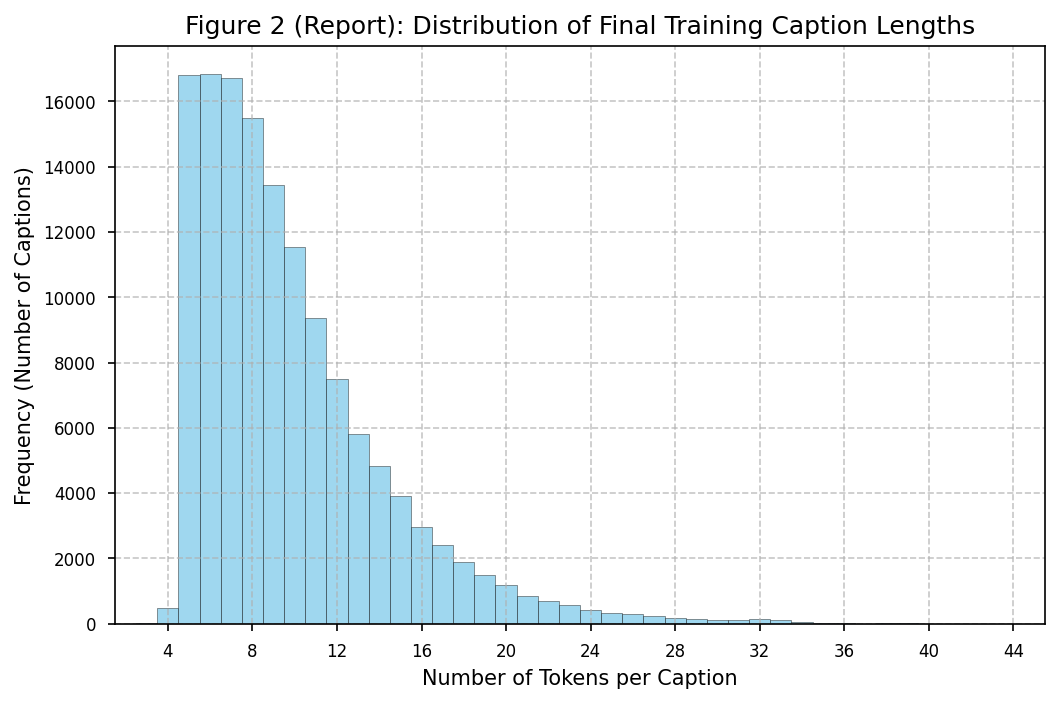


Final Caption Length Statistics:
count    137112.000000
mean          9.793271
std           4.530943
min           2.000000
25%           7.000000
50%           9.000000
75%          12.000000
max          45.000000
Name: caption_length, dtype: float64

Calculating final vocabulary size and common words...

Final Approximate Vocabulary Size: 21,281

Generating Figure 3 (Report): Top 30 Most Common Tokens...

Figure 3 (Common Words Bar Chart) saved to figures/figure_3_final_common_words_bar.png


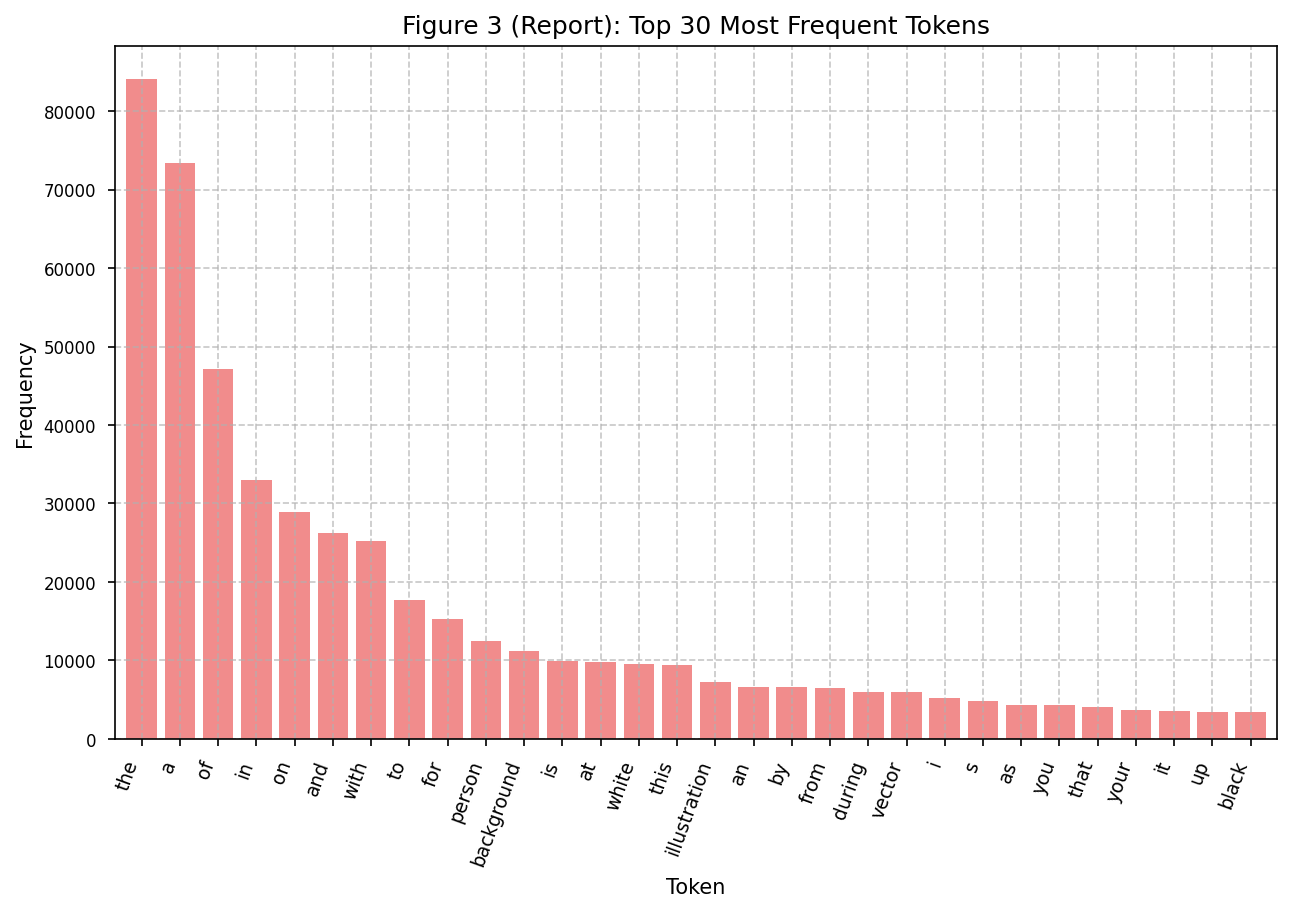


Top 30 Most Common Words (Final Data):
- the: 84,102
- a: 73,368
- of: 47,079
- in: 33,002
- on: 28,927
- and: 26,251
- with: 25,221
- to: 17,756
- for: 15,306
- person: 12,510
- background: 11,179
- is: 9,965
- at: 9,737
- white: 9,503
- this: 9,439
- illustration: 7,305
- an: 6,654
- by: 6,611
- from: 6,491
- during: 5,994
- vector: 5,960
- i: 5,173
- s: 4,832
- as: 4,331
- you: 4,320
- that: 4,053
- your: 3,632
- it: 3,597
- up: 3,488
- black: 3,468

Text analysis visualization complete.


In [27]:
# Ensure the DataFrame is not empty before proceeding with analysis
if valid_train_df.empty:
    print("\nSkipping text analysis as the validated training DataFrame is empty or could not be loaded.")
else:
    print("\n--- Performing Text Analysis on Final Loaded Training Data ---")

    # --- Re-tokenize Captions ---
    # Necessary because the 'tokens' column is list-like and might not save/load well in all formats (esp. CSV)
    # Ensure 'cleaned_caption' column exists and handle potential NaN values if loading failed partially
    if 'cleaned_caption' not in valid_train_df.columns:
         print("ERROR: 'cleaned_caption' column missing from loaded data. Cannot perform text analysis.")
    else:
        print("Tokenizing cleaned captions...")
        # Ensure all entries are strings before splitting
        valid_train_df['cleaned_caption'] = valid_train_df['cleaned_caption'].astype(str)
        valid_train_df['tokens'] = valid_train_df['cleaned_caption'].str.split()

        # --- 1. Caption Length Distribution ---
        print("Calculating final caption length distribution...")
        # Ensure 'tokens' column exists and handle potential None/NaN before len()
        valid_train_df['tokens'] = valid_train_df['tokens'].fillna('') # Replace potential NaNs with empty list/string
        valid_train_df['caption_length'] = valid_train_df['tokens'].apply(len)

        plt.figure(figsize=(8, 5))
        # Handle potential edge case where min > max if df becomes unexpectedly empty
        min_len = valid_train_df['caption_length'].min() if not valid_train_df.empty else 0
        max_len = valid_train_df['caption_length'].max() if not valid_train_df.empty else 1
        min_len = int(min_len) # Ensure integer for range
        max_len = int(max_len) # Ensure integer for range

        # Create bins of width 1, centered on integers
        bins = np.arange(min_len, max_len + 2) - 0.5 if max_len >= min_len else [0, 1]

        plt.hist(valid_train_df['caption_length'], bins=bins, color='skyblue', edgecolor='black', alpha=0.8)
        plt.title('Figure 2 (Report): Distribution of Final Training Caption Lengths')
        plt.xlabel('Number of Tokens per Caption')
        plt.ylabel('Frequency (Number of Captions)')
        # Adjust x-ticks for better readability based on the range
        plt.xticks(np.arange(0, max_len + 1, step=max(1, ((max_len - min_len) // 10) if max_len > min_len else 1)))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        if max_len >= min_len: # Prevent error if max_len < min_len (empty df)
            plt.xlim(bins[0], bins[-1]) # Ensure limits match bins
        else:
            plt.xlim(0, 1) # Default limits for empty case

        # Save the figure
        figure_path_hist = os.path.join(FIGURE_SAVE_DIR, "figure_2_final_caption_length_hist.png")
        plt.savefig(figure_path_hist)
        print(f"\nFigure 2 (Caption Length Histogram) saved to {figure_path_hist}")
        plt.show()

        print("\nFinal Caption Length Statistics:")
        print(valid_train_df['caption_length'].describe())

        # --- 2. Vocabulary Size & Common Words ---
        print("\nCalculating final vocabulary size and common words...")
        # Flatten the list of tokens and handle potential errors if 'tokens' is not list-like
        try:
            all_tokens = [token for sublist in valid_train_df['tokens'].tolist() if isinstance(sublist, list) for token in sublist]
        except TypeError:
            print("Warning: Could not process 'tokens' column for vocabulary analysis. Ensure it contains lists of strings.")
            all_tokens = []

        if all_tokens:
            vocabulary = set(all_tokens)
            vocab_size = len(vocabulary)
            print(f"\nFinal Approximate Vocabulary Size: {vocab_size:,}")

            token_counts = Counter(all_tokens)
            most_common_tokens = token_counts.most_common(NUM_COMMON_WORDS_TO_PLOT)

            if most_common_tokens: # Check if list is not empty
                words, counts = zip(*most_common_tokens) # Unzip
            else:
                words, counts = [], []

            print(f"\nGenerating Figure 3 (Report): Top {NUM_COMMON_WORDS_TO_PLOT} Most Common Tokens...")
            plt.figure(figsize=(10, 6))
            plt.bar(words, counts, color='lightcoral', alpha=0.9)
            plt.title(f'Figure 3 (Report): Top {NUM_COMMON_WORDS_TO_PLOT} Most Frequent Tokens')
            plt.xlabel('Token')
            plt.ylabel('Frequency')
            plt.xticks(rotation=70, ha='right', fontsize=9) # Rotate labels heavily, adjust font size
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.margins(x=0.01) # Reduce horizontal padding

            # Save the figure
            figure_path_bar = os.path.join(FIGURE_SAVE_DIR, "figure_3_final_common_words_bar.png")
            plt.savefig(figure_path_bar)
            print(f"\nFigure 3 (Common Words Bar Chart) saved to {figure_path_bar}")
            plt.show()

            print(f"\nTop {NUM_COMMON_WORDS_TO_PLOT} Most Common Words (Final Data):")
            for word, count in most_common_tokens:
                print(f"- {word}: {count:,}")
        else:
            print("\nNo tokens found to calculate vocabulary size or common words.")

        print("\nText analysis visualization complete.")

## 9. Exporting Final Data for Training

Select the essential columns (local `image_path` and the cleaned text representation, e.g., `cleaned_caption`) from the validated dataframes. Save these refined datasets, ready for a model training pipeline. Parquet format is recommended for efficiency.

In [28]:
# --- Define Final Output Paths for Model Training Data ---
final_train_output_parquet = os.path.join(DATA_PATH, "final_train_data_for_model.parquet")
final_val_output_parquet = os.path.join(DATA_PATH, "final_val_data_for_model.parquet")

# --- Select Columns and Export Training Data ---
if not valid_train_df.empty and 'image_path' in valid_train_df.columns and 'cleaned_caption' in valid_train_df.columns:
    print(f"\nSelecting columns and exporting final training data ({len(valid_train_df):,} samples) for modeling...")
    # Select columns needed for training (image path and text)
    final_train_data = valid_train_df[['image_path', 'cleaned_caption']].copy()
    # Optional: Rename columns if your training script expects specific names
    # final_train_data = final_train_data.rename(columns={'cleaned_caption': 'text'})

    # Save to Parquet
    try:
        final_train_data.to_parquet(final_train_output_parquet, index=False)
        print(f"Final training data saved to: {final_train_output_parquet}")
        print("\nTraining Data Head (for model):")
        print(final_train_data.head())
    except Exception as e:
        print(f"Error exporting final training data: {e}")
else:
    print("Validated training DataFrame is empty or missing required columns ('image_path', 'cleaned_caption'). Skipping export.")

# --- Select Columns and Export Validation Data ---
if not valid_val_df.empty and 'image_path' in valid_val_df.columns and 'cleaned_caption' in valid_val_df.columns:
    print(f"\nSelecting columns and exporting final validation data ({len(valid_val_df):,} samples) for modeling...")
    # Select columns needed for validation
    final_val_data = valid_val_df[['image_path', 'cleaned_caption']].copy()
    # Optional: Rename columns
    # final_val_data = final_val_data.rename(columns={'cleaned_caption': 'text'})

    # Save to Parquet
    try:
        final_val_data.to_parquet(final_val_output_parquet, index=False)
        print(f"Final validation data saved to: {final_val_output_parquet}")
        print("\nValidation Data Head (for model):")
        print(final_val_data.head())
    except Exception as e:
        print(f"Error exporting final validation data: {e}")
else:
    print("\nValidated validation DataFrame is empty or missing required columns ('image_path', 'cleaned_caption'). Skipping export.")

print("\n--- Data Export for Training Complete ---")


Selecting columns and exporting final training data (137,112 samples) for modeling...
Final training data saved to: data/final_train_data_for_model.parquet

Training Data Head (for model):
                image_path                                    cleaned_caption
0  data\train_images\0.jpg                         a very typical bus station
1  data\train_images\3.jpg  interior design of modern living room with fir...
2  data\train_images\5.jpg  the jetty different types of plants to establi...
3  data\train_images\6.jpg     traditional ornamental floral paisley bandanna
4  data\train_images\7.jpg  of the sports team skates against sports team ...

Selecting columns and exporting final validation data (11,013 samples) for modeling...
Final validation data saved to: data/final_val_data_for_model.parquet

Validation Data Head (for model):
               image_path                                    cleaned_caption
0   data\val_images\0.jpg           author a life in photography in pict

## 10. Conclusion

This notebook successfully loaded the GCC caption, validation, and label data. It merged the training captions with the available labels, cleaned the text data, created a development subset, defined functions for downloading/validating images (with an optional execution step), saved/loaded the processed dataframes containing local image paths and cleaned text, performed text analysis on the validated data, and finally exported the essential columns into new files (`final_train_data_for_model.parquet` and `final_val_data_for_model.parquet`) ready for model training.